Projeler: Senin listenden 7 tane:

Yapay Sinir Ağları ile Görüntü Sınıflandırma (MLP) -yapmıştım tekrar yapmicam

CNN ile Rakam Görüntüsü Sınıflandırma (MNIST) -yapmıştım tekrar yapmicam

LSTM ile Film Yorumları Duygu Analizi

GAN ile Görüntü Oluşturma

Transformers ile Duygu Analizi (Text)

Autoencoder ile Moda Görüntüleri (Fashion-MNIST)

Transfer Learning ile İlaç Görüntüleri Sınıflandırma

**Transfer Learning ile İlaç Görüntüleri Sınıflandırma**

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


Epoch [1/3], Train Loss: 2.0077, Train Acc: 0.17, Val Loss: 2.1994, Val Acc: 0.38
Epoch [2/3], Train Loss: 1.3275, Train Acc: 0.42, Val Loss: 3.5847, Val Acc: 0.12
Epoch [3/3], Train Loss: 0.7978, Train Acc: 0.69, Val Loss: 4.5770, Val Acc: 0.12


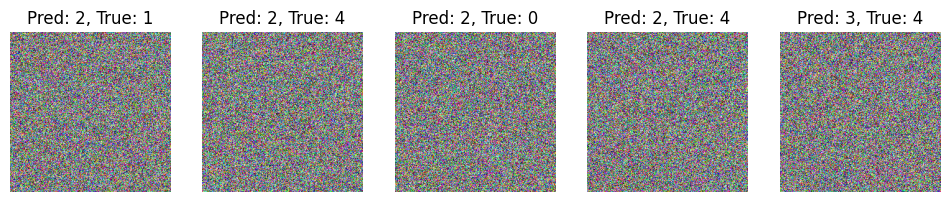

In [1]:
# 🔹 1️⃣ Kütüphaneler
import torch  # tensor işlemleri ve GPU kullanımı
import torch.nn as nn  # sinir ağı katmanları
import torch.optim as optim  # optimizer (model ağırlıklarını güncellemek için)
from torchvision import datasets, transforms, models  # hazır datasetler, dönüşümler ve pretrained modeller
from torch.utils.data import DataLoader, random_split  # dataset bölme ve loader
import matplotlib.pyplot as plt  # görselleştirme

# 🔹 2️⃣ Device (GPU/CPU kontrolü)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU varsa kullan, yoksa CPU

# 🔹 3️⃣ Data Augmentation ve Dönüşümler
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet gibi modeller 224x224 bekler
    transforms.RandomHorizontalFlip(),  # veri çoğaltma için yatay çevirme
    transforms.ToTensor(),  # 0-255 → 0-1 aralığı
])

# 🔹 4️⃣ Dummy Dataset Oluşturma (demo amaçlı)
# Normalde burada gerçek ilaç datasetiniz olur
# Burada MNIST yerine renkli küçük görüntülerle gösterim yapıyoruz
dataset = datasets.FakeData(
    size=200,  # 200 resim
    image_size=(3,224,224),  # 3 kanal RGB, 224x224
    num_classes=5,  # 5 farklı ilaç sınıfı gibi düşün
    transform=transform
)

# 🔹 5️⃣ Train / Validation Split
train_size = int(0.8 * len(dataset))  # %80 train
val_size = len(dataset) - train_size  # %20 validation
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])  # böl

# 🔹 6️⃣ DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)  # batch=16, karıştır
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)  # validation

# 🔹 7️⃣ Pretrained Model Yükle
model = models.resnet18(pretrained=True)  # ImageNet üzerinde önceden eğitilmiş ResNet18
num_features = model.fc.in_features  # son fully connected katmanın input boyutu
model.fc = nn.Linear(num_features, 5)  # son katmanı 5 sınıf için değiştir
model = model.to(device)  # GPU/CPU'ya taşı

# 🔹 8️⃣ Loss ve Optimizer
criterion = nn.CrossEntropyLoss()  # çok sınıflı sınıflandırma loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # ağırlıkları güncelle

# 🔹 9️⃣ Eğitim Döngüsü
num_epochs = 3  # demo için 3 epoch yeterli

for epoch in range(num_epochs):
    model.train()  # training mod
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # GPU/CPU’ya taşı

        optimizer.zero_grad()  # gradientleri sıfırla
        outputs = model(images)  # forward pass
        loss = criterion(outputs, labels)  # loss hesapla
        loss.backward()  # backpropagation
        optimizer.step()  # ağırlıkları güncelle

        running_loss += loss.item() * images.size(0)  # toplam loss
        _, predicted = torch.max(outputs, 1)  # en yüksek olasılık sınıfı
        total += labels.size(0)  # toplam örnek
        correct += (predicted == labels).sum().item()  # doğru tahmin sayısı

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()  # evaluation mod
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():  # gradient hesaplama yok
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs,1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}")

# 🔹 10️⃣ Modelin Bazı Örnek Tahminlerini Gösterme
dataiter = iter(val_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = torch.max(outputs,1)

plt.figure(figsize=(12,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i].cpu().permute(1,2,0))  # CHW → HWC
    plt.title(f"Pred: {predicted[i].item()}, True: {labels[i].item()}")
    plt.axis('off')
plt.show()